In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista6/Zad1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import time

In [2]:
K = 6
R = 10.0

angles = np.linspace(0, 2 * np.pi, K, endpoint=False)

x_centers = R * np.cos(angles)
y_centers = R * np.sin(angles)

cluster_centers = np.column_stack((x_centers, y_centers))

In [3]:
M = 200
sigma = 2

cov = np.diag([sigma**2, sigma**2])

all_data = []
true_labels = []

In [4]:
for i, center in enumerate(cluster_centers):
    points = np.random.multivariate_normal(center, cov, M)
    all_data.append(points)
    true_labels.append(np.full(M, i))

data = np.concatenate(all_data)
true_labels = np.concatenate(true_labels)

print(f"Całkowity zbiór danych: {data.shape}")
print(f"Prawdziwe etykiety: {true_labels.shape}")

Całkowity zbiór danych: (1200, 2)
Prawdziwe etykiety: (1200,)


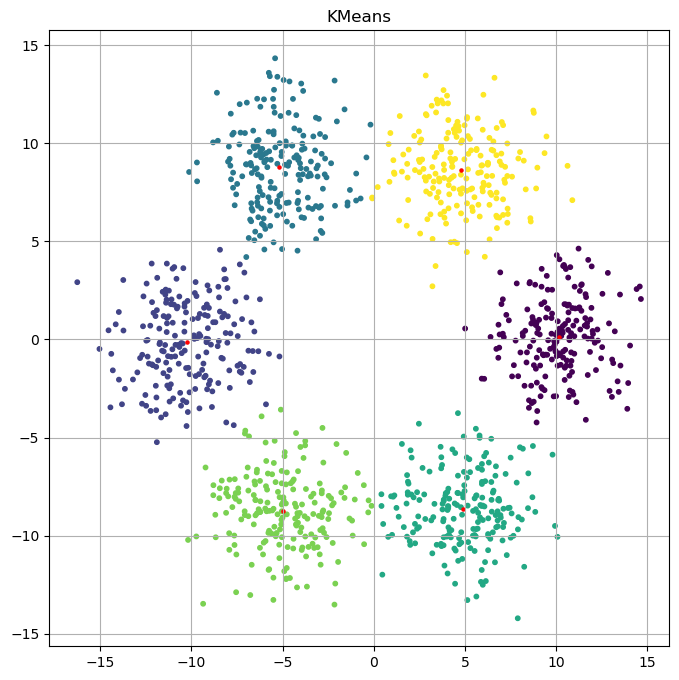

In [5]:
kmeans = KMeans(n_clusters=K, random_state=2137, n_init=20)
kmeans_labels = kmeans.fit_predict(data)


plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], c=kmeans_labels, s=10)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=20, c='red', marker='.')
plt.title("KMeans")
plt.grid(True)
plt.show()

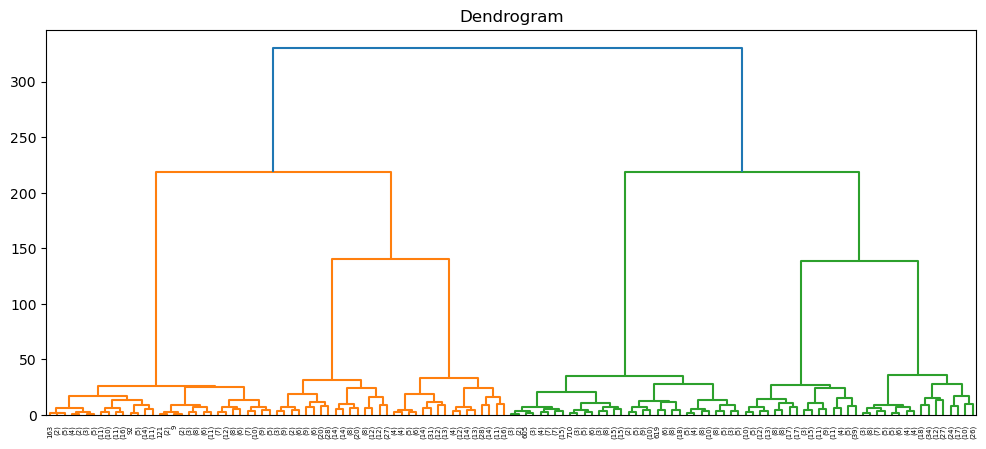

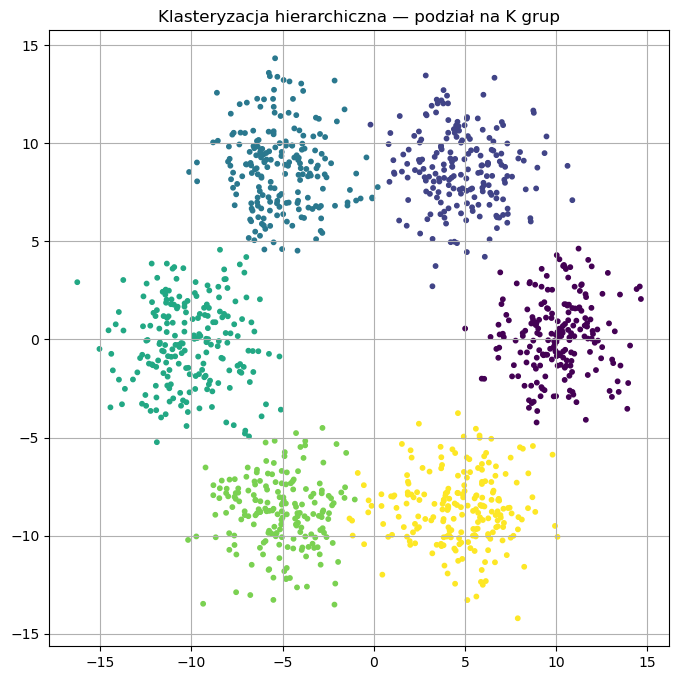

In [6]:
Z = linkage(data, method='ward')

plt.figure(figsize=(12, 5))
plt.title("Dendrogram")
dendrogram(Z, truncate_mode="level", p=6)
plt.show()

hier_labels = fcluster(Z, K, criterion='maxclust')

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], c=hier_labels, s=10)
plt.title("Klasteryzacja hierarchiczna — podział na K grup")
plt.grid(True)
plt.show()

In [7]:
print("\n=== KMeans dla różnych liczby klastrów ===")
for k in range(2, K + 1):
    km = KMeans(n_clusters=k, n_init=20).fit(data)
    ari = adjusted_rand_score(true_labels, km.labels_)
    print(f"k={k}: ARI={ari:.4f}")



=== KMeans dla różnych liczby klastrów ===
k=2: ARI=0.3291
k=3: ARI=0.5576
k=4: ARI=0.5947
k=5: ARI=0.7548
k=6: ARI=0.9722


ARI = Adjusted Rand Index

ARI = (RI - Expected_RI) / (max(RI) - Expected_RI)

RI = (TP + TN) / ALL 

gdzie zliczamy par elemtnów (x, y) i czy pasują klastry [predicted/true] (ten sam, ten sam) (ten sam, inny) (inny, ten sam) (inny, inny)

Im więcej tym lepiej, im bliżej 1

In [8]:
def test_kmeans_speed(K, M, sigma, R=40, batch_size=5000, seed=2137):

    print("\n=============================================")
    print(f" Test: K={K}, M={M}, sigma={sigma}, R={R}")
    print("=============================================")

    np.random.seed(seed)

    angles = np.linspace(0, 2*np.pi, K, endpoint=False)
    centers = np.column_stack((R * np.cos(angles),
                               R * np.sin(angles)))
    
    cov = np.diag([sigma**2, sigma**2])
    data = []
    labels = []

    for i, center in enumerate(centers):
        pts = np.random.multivariate_normal(center, cov, M)
        data.append(pts)
        labels.append(np.full(M, i))

    data = np.vstack(data)
    labels = np.concatenate(labels)

    print(f" Rozmiar danych: {data.shape[0]:,} punktów x {data.shape[1]} wymiarów")

    # --- KMeans ---
    t0 = time.time()
    km = KMeans(n_clusters=K, n_init=5, random_state=seed).fit(data)
    t_kmeans = time.time() - t0
    ari_km = adjusted_rand_score(labels, km.labels_)

    # --- MiniBatchKMeans ---
    t0 = time.time()
    mbkm = MiniBatchKMeans(
        n_clusters=K,
        batch_size=batch_size,
        random_state=seed
    ).fit(data)
    t_mb = time.time() - t0
    ari_mb = adjusted_rand_score(labels, mbkm.labels_)

    # --- Wyniki ---
    print("\n--- Wyniki ---")
    print(f"KMeans:           czas = {t_kmeans:.2f} s, ARI = {ari_km:.4f}")
    print(f"MiniBatchKMeans:  czas = {t_mb:.2f} s, ARI = {ari_mb:.4f}")
    
    return {
        "KMeans_time": t_kmeans,
        "KMeans_ARI": ari_km,
        "MiniBatch_time": t_mb,
        "MiniBatch_ARI": ari_mb,
        "size": data.shape[0]
    }

In [9]:
res_medium = test_kmeans_speed(K=50, M=2000, sigma=1.0)


 Test: K=50, M=2000, sigma=1.0, R=40
 Rozmiar danych: 100,000 punktów x 2 wymiarów

--- Wyniki ---
KMeans:           czas = 0.50 s, ARI = 0.9453
MiniBatchKMeans:  czas = 0.04 s, ARI = 0.9448


In [10]:
res_large = test_kmeans_speed(K=500, M=1000, sigma=1)


 Test: K=500, M=1000, sigma=1, R=40
 Rozmiar danych: 500,000 punktów x 2 wymiarów

--- Wyniki ---
KMeans:           czas = 74.26 s, ARI = 0.1331
MiniBatchKMeans:  czas = 0.49 s, ARI = 0.1336


In [ ]:
res_large = test_kmeans_speed(K=1000, M=1000, sigma=1)


 Test: K=1000, M=1000, sigma=1, R=40
 Rozmiar danych: 1,000,000 punktów x 2 wymiarów


In [11]:
res_large = test_kmeans_speed(K=500, M=1000, sigma=0.5)


 Test: K=500, M=1000, sigma=0.5, R=40
 Rozmiar danych: 500,000 punktów x 2 wymiarów

--- Wyniki ---
KMeans:           czas = 67.87 s, ARI = 0.2468
MiniBatchKMeans:  czas = 0.46 s, ARI = 0.2471
